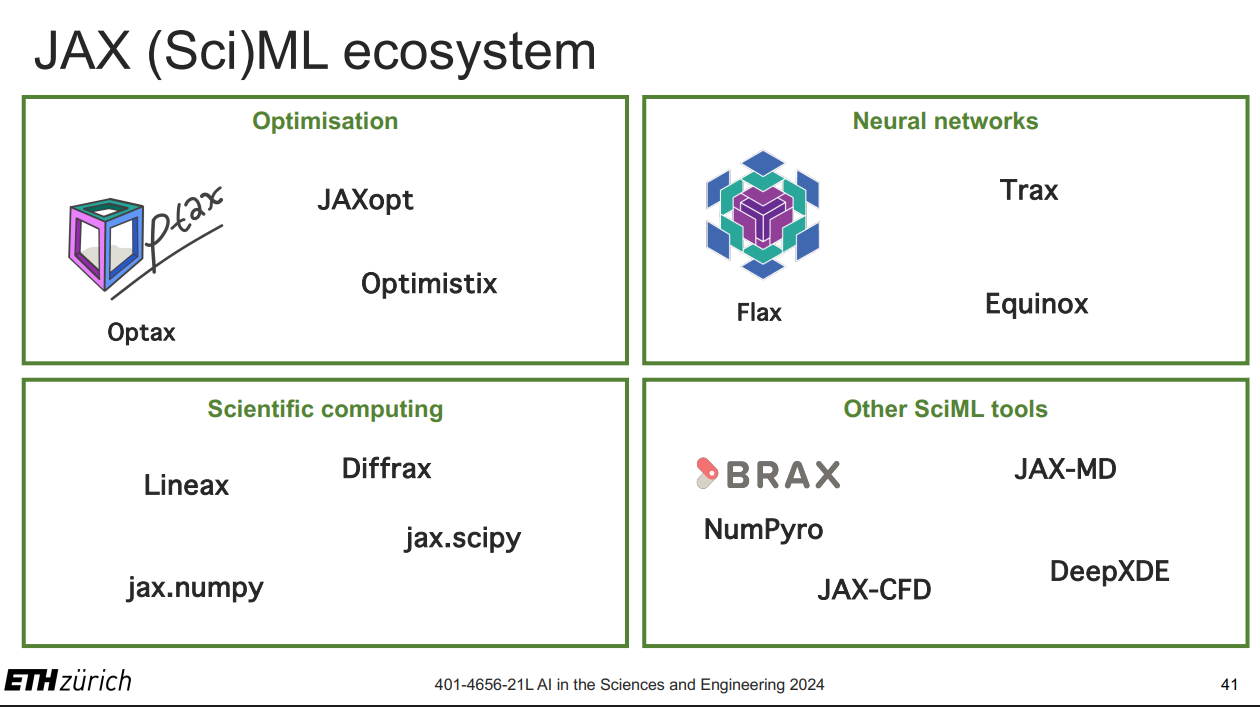

## 🪆 Flax Linen — Thư viện Mạng Nơ-ron trên nền JAX

### ⚙️ Điểm khác biệt cốt lõi: Triết lý Phi trạng thái (Stateless)
Không giống như PyTorch (nơi mô hình tự lưu trữ và thay đổi trọng số của chính nó), Flax tách biệt hoàn toàn **Định nghĩa Mô hình** khỏi **Trạng thái Tham số (Parameters)**:
* **Mô hình (`model`):** Chỉ là một cái khung chứa công thức toán và cấu trúc các tầng mạng, hoàn toàn không chứa dữ liệu trọng số.
* **Tham số (`params`):** Được lưu trữ độc lập bên ngoài dưới dạng một từ điển `pytree dict` cấu trúc phẳng. Muốn chạy mạng, bạn phải truyền tường minh cả `params` và dữ liệu đầu vào thông qua hàm `model.apply`.

In [ ]:
import jax
import jax.numpy as jnp
import flax.linen as nn
import optax
import numpy as np
import matplotlib.pyplot as plt
from functools import partial

print(f'JAX: {jax.__version__}')
import flax; print(f'Flax: {flax.__version__}')
print(f'Optax: {optax.__version__}')

key = jax.random.PRNGKey(42)

JAX: 0.7.2
Flax: 0.11.2
Optax: 0.2.8


## 1. Sinh dữ liệu thực nghiệm (Generate Dataset)

In [ ]:
# Heat flux: Q = h * A * delta_T
N = 2000
key, k1, k2, k3, kn = jax.random.split(key, 5)

h       = jax.random.uniform(k1, (N, 1)) * 100 + 10
A       = jax.random.uniform(k2, (N, 1)) * 0.5 + 0.01
delta_T = jax.random.uniform(k3, (N, 1)) * 80 + 5

X = jnp.concatenate([h, A, delta_T], axis=1)   # (N, 3)
y = (h * A * delta_T)[:, 0]                     # (N,)  — scalar output
y = y + 0.02 * y * jax.random.normal(kn, (N,))  # add noise

# Normalize
X_mean, X_std = X.mean(0), X.std(0)
y_mean, y_std = y.mean(), y.std()
X_norm = (X - X_mean) / X_std
y_norm = (y - y_mean) / y_std

# Train / val split
split = int(0.8 * N)
X_train, X_val = X_norm[:split], X_norm[split:]
y_train, y_val = y_norm[:split], y_norm[split:]

print(f'Train: {X_train.shape}, Val: {X_val.shape}')

Train: (1600, 3), Val: (400, 3)


### 🌟 Định nghĩa mạng siêu gọn với `@nn.compact`
Để xây dựng kiến trúc mạng, bạn chỉ cần kế thừa lớp `nn.Module`. Đặc biệt, decorator **`@nn.compact`** của Flax mang lại sự tiện lợi vượt trội:
* **Khai báo dòng (Inline definition):** Cho phép bạn vừa khởi tạo vừa áp dụng các tầng mạng con (như `nn.Dense`, `nn.Conv`) ngay trong hàm tính toán `__call__`.
* **Đơn giản hóa mã nguồn:** Loại bỏ hoàn toàn việc phải viết riêng một hàm khởi tạo phức tạp (như `__init__` trong PyTorch), giúp cấu trúc khai báo mạng trở nên cực kỳ gọn gàng và dễ đọc.

## 2. Define MLP with Flax

In [ ]:
class MLP(nn.Module):
    hidden_dims: tuple = (128, 128, 64)
    out_dim: int = 1

    @nn.compact
    def __call__(self, x):
        for h in self.hidden_dims:
            x = nn.Dense(h)(x)
            x = nn.relu(x)
        return nn.Dense(self.out_dim)(x)[:, 0]  # (batch,)

model = MLP()

# Initialize — JAX requires explicit shapes
key, init_key = jax.random.split(key)
params = model.init(init_key, jnp.ones((1, 3)))['params']

# Inspect structure
print('Parameter tree structure:')
for layer, p in params.items():
    for name, val in p.items():
        print(f'  {layer}/{name}: {val.shape}')

Parameter tree structure:
  Dense_0/kernel: (3, 128)
  Dense_0/bias: (128,)
  Dense_1/kernel: (128, 128)
  Dense_1/bias: (128,)
  Dense_2/kernel: (128, 64)
  Dense_2/bias: (64,)
  Dense_3/kernel: (64, 1)
  Dense_3/bias: (1,)


 # 3. Loss Function and Training Step

In [ ]:
def mse_loss(params, X, y):
    preds = model.apply({'params': params}, X)
    return jnp.mean((preds - y) ** 2)

# Optimizer
optimizer = optax.adam(learning_rate=1e-3)
opt_state = optimizer.init(params)

@jax.jit
def train_step(params, opt_state, X_batch, y_batch):
    loss, grads = jax.value_and_grad(mse_loss)(params, X_batch, y_batch)
    updates, new_opt_state = optimizer.update(grads, opt_state, params)
    new_params = optax.apply_updates(params, updates)
    return new_params, new_opt_state, loss

@jax.jit
def eval_loss(params, X, y):
    return mse_loss(params, X, y)

print('Train step compiled (first call will be slow — that is expected).')

Train step compiled (first call will be slow — that is expected).


# 4. Training Loop

In [ ]:
BATCH_SIZE = 64
NUM_EPOCHS = 100
N_TRAIN = X_train.shape[0]

train_losses, val_losses = [], []

for epoch in range(NUM_EPOCHS):
    # Shuffle training data
    key, shuffle_key = jax.random.split(key)
    perm = jax.random.permutation(shuffle_key, N_TRAIN)
    X_shuffled, y_shuffled = X_train[perm], y_train[perm]

    epoch_loss = 0.0
    n_batches = N_TRAIN // BATCH_SIZE

    for i in range(n_batches):
        X_batch = X_shuffled[i * BATCH_SIZE:(i + 1) * BATCH_SIZE]
        y_batch = y_shuffled[i * BATCH_SIZE:(i + 1) * BATCH_SIZE]
        params, opt_state, loss = train_step(params, opt_state, X_batch, y_batch)
        epoch_loss += loss

    train_losses.append(float(epoch_loss / n_batches))
    val_losses.append(float(eval_loss(params, X_val, y_val)))

    if (epoch + 1) % 10 == 0:
        print(f'Epoch {epoch+1:3d}/{NUM_EPOCHS}  '
              f'Train: {train_losses[-1]:.4f}  Val: {val_losses[-1]:.4f}')


Epoch  10/100  Train: 0.0067  Val: 0.0089
Epoch  20/100  Train: 0.0049  Val: 0.0058
Epoch  30/100  Train: 0.0036  Val: 0.0047
Epoch  40/100  Train: 0.0021  Val: 0.0036
Epoch  50/100  Train: 0.0017  Val: 0.0024
Epoch  60/100  Train: 0.0015  Val: 0.0029
Epoch  70/100  Train: 0.0016  Val: 0.0023
Epoch  80/100  Train: 0.0013  Val: 0.0021
Epoch  90/100  Train: 0.0012  Val: 0.0024
Epoch 100/100  Train: 0.0010  Val: 0.0019


# 5. Plot Loss Curves

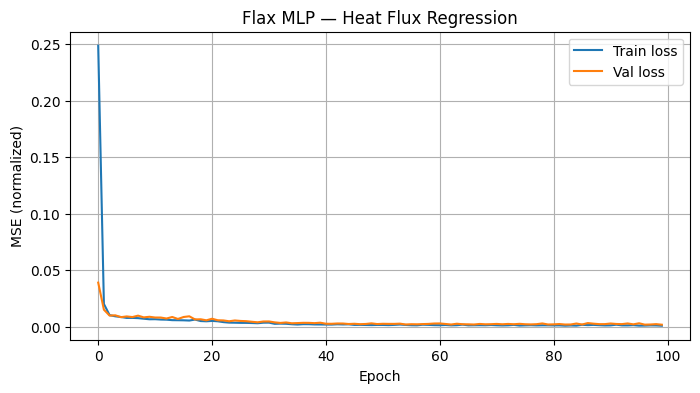

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label='Train loss')
plt.plot(val_losses, label='Val loss')
plt.xlabel('Epoch')
plt.ylabel('MSE (normalized)')
plt.title('Flax MLP — Heat Flux Regression')
plt.legend()
plt.grid(True)
plt.show()

# 6. Evaluate: Predicted vs True

Val MSE (original scale): 995.12
Val MAE (original scale): 18.93


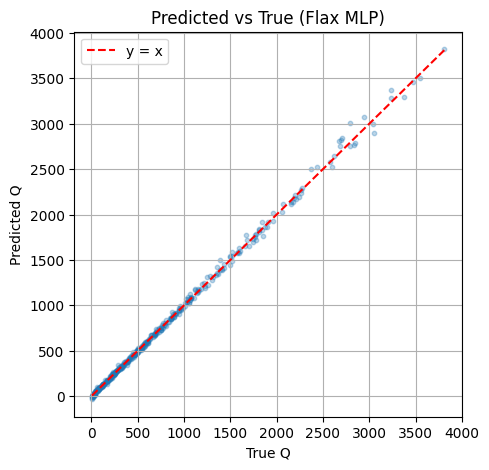

In [ ]:
y_pred_norm = model.apply({'params': params}, X_val)
y_pred = np.array(y_pred_norm) * float(y_std) + float(y_mean)
y_true = np.array(y_val) * float(y_std) + float(y_mean)

mse = np.mean((y_pred - y_true) ** 2)
mae = np.mean(np.abs(y_pred - y_true))
print(f'Val MSE (original scale): {mse:.2f}')
print(f'Val MAE (original scale): {mae:.2f}')

plt.figure(figsize=(5, 5))
plt.scatter(y_true, y_pred, alpha=0.3, s=10)
lim = [y_true.min(), y_true.max()]
plt.plot(lim, lim, 'r--', label='y = x')
plt.xlabel('True Q')
plt.ylabel('Predicted Q')
plt.title('Predicted vs True (Flax MLP)')
plt.legend()
plt.grid(True)
plt.show()


### Bảng so sánh chi tiết: PyTorch vs JAX/Flax

| Tiêu chí so sánh | PyTorch (Hướng đối tượng - OOP) | JAX / Flax (Lập trình hàm) |
| :--- | :--- | :--- |
| **Định nghĩa Mô hình** | `class Net(nn.Module): def forward(self, x)` | `class Net(nn.Module): def __call__(self, x)` |
| **Quản lý Tham số** | Nằm ẩn bên trong đối tượng mô hình (`model.parameters()`) | Tách riêng biệt dưới dạng một từ điển `pytree dict` (`params`) |
| **Lan truyền xuôi (Forward)** | `model(x)` | `model.apply({'params': params}, x)` |
| **Tính Đạo hàm (Gradient)** | `loss.backward()` (Tự gán vào thuộc tính `.grad` của biến) | `jax.grad(loss_fn)(params, ...)` (Trả về một hàm tính đạo hàm) |
| **Cập nhật Trọng số** | `optim.step()` (Sửa đổi trực tiếp lên trọng số cũ) | `optax.update` + `optax.apply_updates` (Tạo ra bộ tham số mới) |
| **Biên dịch tăng tốc (JIT)** | `torch.compile(model)` (Chạy ngầm ở tầng dưới) | Sử dụng decorator `@jax.jit` trực tiếp trên hàm `train_step` |
| **Trạng thái (State)** | **Mutable**: Trạng thái thay đổi liên tục bên trong mô hình | **Immutable**: Trạng thái được mang theo tường minh qua các hàm |